In [1]:
import json
import re
from dataclasses import dataclass

import pandas as pd

In [2]:
from pathlib import Path
import pandas as pd

data_path = Path.cwd().parent / "data" / "moses.csv"
df = pd.read_csv(data_path)

In [4]:
df.SPLIT.value_counts()

SPLIT
train             1574663
test_scaffolds     176225
test               176074
val                 10000
Name: count, dtype: int64

In [18]:
examples = pd.read_csv("../main/test_data/references.csv", nrows=1000)

In [14]:
@dataclass
class Molecule:
    pepmass: float = None
    charge: str = ""
    mslevel: int = None
    feature_id: int = None
    source_instrument: str = ""
    ionmode: str = ""
    name: str = ""
    pi: str = ""
    datacollector: str = ""
    taxonomy: str = ""
    smiles: str = ""
    pubchem: str = ""
    spectrum: pd.DataFrame = None

    def __str__(self):
        return f"""
pepmass={self.pepmass}
charge={self.charge}
mslevel={self.mslevel}
feature_id={self.feature_id}
source_instrument={self.source_instrument}
ionmode={self.ionmode}
name={self.name}
pi={self.pi}
datacollector={self.datacollector}
taxonomy={self.taxonomy}
smiles={self.smiles}
pubchem={self.pubchem}
spectrum=\n{self.spectrum}
"""
    def __repr__(self):
        return self.__str__()

types = dict(
    pepmass=float,
    mslevel=int,
    feature_id=int
)

In [21]:
examples.head(2)

,spectral_data_id,pepmass,num_peaks,peaks_list,data_id,smiles,compound_name,database_name,path_to_data,json_file,filename,charge
0,191,219.0400,19,87.056 0.028\n130.067 0.007\n132.083 0.223\n13...,191,O=c1c2ccccc2oc2ccccc12,"9H-xanthen-9-one, (level ***)",POS_LC,/data/frederic/ToBeInserted/Json_DataBase/,POS_LC_molecule0298004_PEPMASS-219.0400.json,/data/frederic/ToBeInserted/Json_DataBase/POS_...,0+
1,192,232.1444,54,53.0386 0.01309889\n54.0339 0.00542928\n55.041...,192,Cc1c(N(C)C)c(=O)n(-c2ccccc2)n1C,"4-Dimethylaminoantipyrine, (level ***)",POS_LC,/data/frederic/ToBeInserted/Json_DataBase/,POS_LC_molecule0354208_PEPMASS-232.1444.json,/data/frederic/ToBeInserted/Json_DataBase/POS_...,0+


In [34]:
mol = Molecule(pepmass=examples.pepmass[0],
               charge=examples.charge[0],
               name=examples.compound_name[0],
               smiles=examples.smiles[0])
spectrum = [(float(values.split(" ")[0]), float(values.split(" ")[1])) for values in examples.loc[0].peaks_list.split("\\n")if values]
spectrum = pd.DataFrame(spectrum, columns=["mass-to-charge", "intensity"])
setattr(mol, "spectrum", spectrum)

In [15]:
molecules = []
for current_position, current_item in enumerate(examples):
    if "BEGIN IONS" in current_item:
        spectrum = []
        mol = Molecule()

        for next_position, next_item in enumerate(examples[current_position+1:]):
            if "END IONS" in next_item:
                break            
            
            if "\t" in next_item:
                val1, val2, _ = next_item.split("\t")
                spectrum.append((float(val1), float(val2)))
            else:
                key, val = next_item.split("=")

                val = val.replace("\n", "")
                key = key.lower()

                if key in types:
                    if not val:
                        val = None
                    else:
                        val = types[key](val)
                setattr(mol, key, val)

        setattr(mol, "spectrum", pd.DataFrame(spectrum, columns=["mass-to-charge", "intensity"]))
        molecules.append(mol)


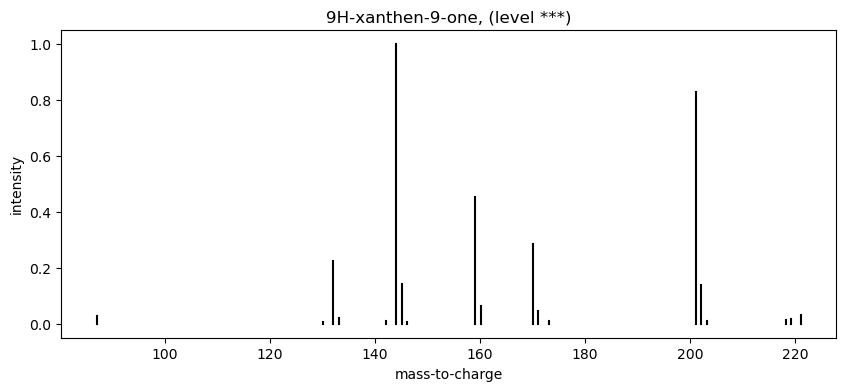

In [39]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
for _, row in mol.spectrum.iterrows():
    plt.plot([row["mass-to-charge"], row["mass-to-charge"]], [0, row["intensity"]], "k-")
plt.xlabel("mass-to-charge")
plt.ylabel("intensity")
plt.title(mol.name)
plt.show()


In [6]:
baseline = molecules[0].spectrum

In [ ]:
def plot_ms(spectrum, normalize=False, xlim=None, ax=None):
    if not ax:
        fig, ax = plt.subplots(1)

    factor = 1
    if normalize:
        factor = spectrum["intensity"].max()

    for _, (mz, intensity) in spectrum.iterrows():
        ax.plot([mz, mz], [0, intensity/factor], "k-")
        ax.plot(mz, intensity/factor, "ko")
    
    if xlim:
        ax.set_xlim(xlim)

    return ax

# Full dataset

In [ ]:
name = "2-Cyano-3,3-diphenylacrylic acid"
sample = [item for item in data if item.get("NAME") == name]
print(f"Found {len(sample)} items")

In [ ]:
fig, axes = plt.subplots(len(sample)+1, 1, figsize=(20, 40))
plot_ms(baseline, True, xlim=(100, 600), ax=axes[0])
for pos, test_case in enumerate(sample):
    peaks = pd.DataFrame([item.split(" ") for item in test_case.get("PEAKS_LIST").split(";")], columns=["mass-to-charge", "intensity"]).astype(float)
    plot_ms(peaks, xlim=(100, 600), ax=axes[pos+1])

## Compare two molecules

In [8]:
baseline = molecules[0]
unknown = molecules[1]

In [11]:
spec_baseline = baseline.spectrum
spec_unknown = unknown.spectrum

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_similarity(spec_baseline.values, spec_unknown.values)

ValueError: Incompatible dimension for X and Y matrices: X.shape[1] == 12 while Y.shape[1] == 81

In [13]:
spec_baseline

,mass-to-charge,intensity
0,121.251839,0.668298
1,125.000038,10.716405
2,146.762100,0.728083
3,184.073715,100.000000
4,270.395264,0.732708
5,313.275238,3.312709
6,319.911499,0.645011
7,478.330139,9.536627
8,496.265503,1.355096
9,496.340790,76.367104


In [14]:
spec_unknown

,mass-to-charge,intensity
0,53.002407,0.894766
1,53.038887,1.019218
2,55.018089,2.344998
3,55.054539,6.184750
4,57.033745,6.832449
...,...,...
76,330.279541,1.924239
77,333.836304,0.471971
78,361.274323,100.000000
79,361.321991,0.547762


In [11]:
smiles_dict = {
    "CCO": "alcohol",
    "CCN": "amine",
    "CCC": "alkane",
    "CCF": "fluoride",
    "NC(C)Cc1ccccc1": "Amphetamine",
    "CCC(C)CC(C)N": "Methylhexanamine",
    "Cl[C@H]=CCl": "1,2-Dichloroéthène",
    "C(=C)(Cl)Cl": "1,1-Dichloroéthène"
}

smiles = list(smiles_dict.keys())
names = list(smiles_dict.values())

# morgan fingerprint + similarity
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
import numpy as np
import pandas as pd

def tanimoto(query_smiles, mol):
    query_mol = Chem.MolFromSmiles(query_smiles)
    query_fp = AllChem.GetMorganFingerprintAsBitVect(query_mol, 2, nBits=2048)
    return DataStructs.TanimotoSimilarity(query_fp, AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(mol), 2, nBits=2048))

mat = np.zeros((len(smiles), len(smiles)))
for mol in smiles:
    for ref in smiles:
        row = smiles.index(mol)
        col = smiles.index(ref)
        mat[row, col] = tanimoto(mol, ref)

print(pd.DataFrame(mat, index=names, columns=names))

                     alcohol     amine    alkane  fluoride  Amphetamine  \
alcohol             1.000000  0.333333  0.428571  0.333333     0.086957   
amine               0.333333  1.000000  0.428571  0.333333     0.136364   
alkane              0.428571  0.428571  1.000000  0.428571     0.095238   
fluoride            0.333333  0.333333  0.428571  1.000000     0.086957   
Amphetamine         0.086957  0.136364  0.095238  0.086957     1.000000   
Methylhexanamine    0.166667  0.235294  0.187500  0.166667     0.259259   
1,2-Dichloroéthène  0.000000  0.000000  0.000000  0.000000     0.000000   
1,1-Dichloroéthène  0.090909  0.000000  0.000000  0.000000     0.000000   

                    Methylhexanamine  1,2-Dichloroéthène  1,1-Dichloroéthène  
alcohol                     0.166667                 0.0            0.090909  
amine                       0.235294                 0.0            0.000000  
alkane                      0.187500                 0.0            0.000000  
fluoride

[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerator
[16:29:25] DEPRECATION WARNING: please use MorganGenerat